# Orbital Debris Population Structure from Public GP Catalog Data

## Research question
Do major debris-producing events occupy distinct altitude–inclination regimes, and how much of the observed altitude structure can be explained by inclination alone?

## Data source
Current General Perturbations (GP) element sets from **CelesTrak** for:

- FENGYUN 1C ASAT debris
- IRIDIUM 33 debris
- COSMOS 2251 debris

This is an exploratory data-analysis project built as an extension of introductory engineering data-analysis coursework.

> **Scope note:** The analysis describes the **current cataloged surviving population** in the downloaded GP data. It does not reconstruct the original debris clouds immediately after each breakup.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, probplot
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## 1. Load current CelesTrak GP data

Each CelesTrak group is downloaded as CSV and tagged with a `debris_event` label before concatenation.

In [3]:
urls = {
    "FENGYUN 1C ASAT Debris": "https://celestrak.org/NORAD/elements/gp.php?GROUP=fengyun-1c-debris&FORMAT=csv",
    "IRIDIUM 33 Debris": "https://celestrak.org/NORAD/elements/gp.php?GROUP=iridium-33-debris&FORMAT=csv",
    "COSMOS 2251 Debris": "https://celestrak.org/NORAD/elements/gp.php?GROUP=cosmos-2251-debris&FORMAT=csv"
}

frames = []

for event_name, url in urls.items():
    df_event = pd.read_csv(url)
    df_event["debris_event"] = event_name
    frames.append(df_event)

debris_raw = pd.concat(frames, ignore_index=True)

print(debris_raw.shape)
debris_raw.head()

(2646, 18)


,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,CLASSIFICATION_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,debris_event
0,FENGYUN 1C,1999-025A,2026-08-27T04:28:48.109152,14.271900,0.001372,98.8607,313.6463,59.1256,301.1272,0,U,25730,999,40808,0.000848,0.000020,0.0,FENGYUN 1C ASAT Debris
1,FENGYUN 1C DEB,1999-025X,2026-08-27T07:21:05.735232,12.968983,0.056405,99.2076,261.1015,327.2701,40.9823,0,U,29733,999,92458,0.001087,0.000006,0.0,FENGYUN 1C ASAT Debris
2,FENGYUN 1C DEB,1999-025Y,2026-08-27T06:39:41.101056,12.920267,0.060611,99.1669,132.1883,140.3892,342.1474,0,U,29734,999,91873,0.002954,0.000018,0.0,FENGYUN 1C ASAT Debris
3,FENGYUN 1C DEB,1999-025Z,2026-08-26T22:10:24.110688,12.758975,0.070389,99.3834,116.1463,325.2810,30.4192,0,U,29735,999,90694,0.001077,0.000006,0.0,FENGYUN 1C ASAT Debris
4,FENGYUN 1C DEB,1999-025AA,2026-08-26T08:13:54.530400,12.577610,0.072387,99.4364,13.9889,8.0280,41.0571,0,U,29736,999,89770,0.000404,0.000002,0.0,FENGYUN 1C ASAT Debris


## 2. Derive physically useful orbital quantities

The CelesTrak GP data provide mean motion in revolutions per day.

Orbital period is computed from

\[
T_{\mathrm{min}}=\frac{1440}{n_{\mathrm{rev/day}}}.
\]

Mean motion is converted to rad/s and used with the two-body relation

\[
a=\left(\frac{\mu}{n^2}\right)^{1/3}
\]

to estimate semi-major axis. An approximate mean altitude proxy is then

\[
h_{\mathrm{approx}}=a-R_E.
\]

This is **not instantaneous altitude**, perigee, or apogee. It is a semi-major-axis-based mean-altitude proxy.

In [5]:
# Constants
MU_EARTH = 398600.4418      # km^3/s^2
R_EARTH = 6378.137          # km

debris = debris_raw.copy()

# Standardize useful columns
debris["mean_motion_rev_per_day"] = pd.to_numeric(debris["MEAN_MOTION"], errors="coerce")
debris["inclination_deg"] = pd.to_numeric(debris["INCLINATION"], errors="coerce")
debris["eccentricity"] = pd.to_numeric(debris["ECCENTRICITY"], errors="coerce")

# Orbital period from mean motion
debris["period_min"] = 1440 / debris["mean_motion_rev_per_day"]

# Convert mean motion to semi-major axis
# mean motion n in rad/s
debris["mean_motion_rad_s"] = debris["mean_motion_rev_per_day"] * 2 * np.pi / 86400
debris["semi_major_axis_km"] = (MU_EARTH / debris["mean_motion_rad_s"]**2)**(1/3)

# Approximate mean altitude
debris["altitude_km"] = debris["semi_major_axis_km"] - R_EARTH

# Clean physically usable rows
debris = debris.dropna(subset=["altitude_km", "inclination_deg", "period_min", "eccentricity"])

# Optional: focus on Earth-orbit values that are plausible for this quick EDA
debris = debris[(debris["altitude_km"] > 100) & (debris["altitude_km"] < 40000)]

print(debris.shape)
debris[["OBJECT_NAME", "debris_event", "inclination_deg", "altitude_km", "period_min", "eccentricity"]].head()

(2646, 25)


,OBJECT_NAME,debris_event,inclination_deg,altitude_km,period_min,eccentricity
0,FENGYUN 1C,FENGYUN 1C ASAT Debris,98.8607,801.138985,100.897569,0.001372
1,FENGYUN 1C DEB,FENGYUN 1C ASAT Debris,99.2076,1274.266983,111.034148,0.056405
2,FENGYUN 1C DEB,FENGYUN 1C ASAT Debris,99.1669,1293.490509,111.452802,0.060611
3,FENGYUN 1C DEB,FENGYUN 1C ASAT Debris,99.3834,1358.008770,112.861728,0.070389
4,FENGYUN 1C DEB,FENGYUN 1C ASAT Debris,99.4364,1432.199599,114.489157,0.072387


## 3. Descriptive statistics

First inspect the overall distributions of inclination, approximate mean altitude, orbital period, and eccentricity.

In [6]:
summary = debris[["inclination_deg", "altitude_km", "period_min", "eccentricity"]].describe()
summary

,inclination_deg,altitude_km,period_min,eccentricity
count,2646.000000,2646.000000,2646.000000,2646.000000
mean,92.865055,804.508150,100.983104,0.011802
std,10.398099,140.808702,2.983609,0.012069
min,73.539700,232.378347,89.148226,0.000067
25%,86.369625,723.516953,99.265650,0.003971
50%,98.691900,803.956804,100.956977,0.007828
75%,98.991900,869.648866,102.345266,0.015659
max,106.188900,1951.380035,126.092560,0.136496


In [7]:
def coefficient_of_variation(x):
    return x.std() / x.mean()

stats_table = pd.DataFrame({
    "mean": debris[["inclination_deg", "altitude_km"]].mean(),
    "median": debris[["inclination_deg", "altitude_km"]].median(),
    "std": debris[["inclination_deg", "altitude_km"]].std(),
    "iqr": debris[["inclination_deg", "altitude_km"]].quantile(0.75) - debris[["inclination_deg", "altitude_km"]].quantile(0.25),
    "cv": debris[["inclination_deg", "altitude_km"]].apply(coefficient_of_variation)
})

stats_table

,mean,median,std,iqr,cv
inclination_deg,92.865055,98.691900,10.398099,12.622275,0.111970
altitude_km,804.508150,803.956804,140.808702,146.131913,0.175025


### Inclination–altitude covariance and correlation

This is an exploratory association measure only. Correlation does not imply that inclination physically causes altitude.

In [8]:
covariance = debris["inclination_deg"].cov(debris["altitude_km"])
correlation = debris["inclination_deg"].corr(debris["altitude_km"])

print(f"Covariance: {covariance:.3f} deg*km")
print(f"Correlation coefficient: {correlation:.3f}")

Covariance: 430.871 deg*km
Correlation coefficient: 0.294


## 4. Visualize population structure

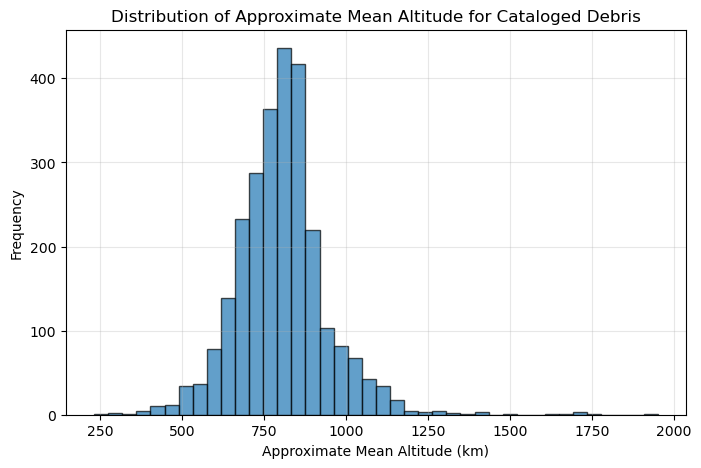

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(debris["altitude_km"], bins=40, edgecolor="black", alpha=0.7)
plt.xlabel("Approximate Mean Altitude (km)")
plt.ylabel("Frequency")
plt.title("Distribution of Approximate Mean Altitude for Cataloged Debris")
plt.grid(alpha=0.3)
plt.show()

<Figure size 1000x500 with 0 Axes>

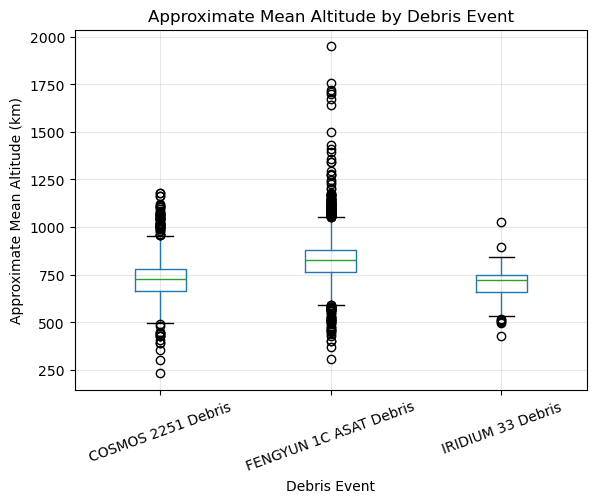

In [10]:
plt.figure(figsize=(10, 5))
debris.boxplot(column="altitude_km", by="debris_event", rot=20)
plt.title("Approximate Mean Altitude by Debris Event")
plt.suptitle("")
plt.xlabel("Debris Event")
plt.ylabel("Approximate Mean Altitude (km)")
plt.grid(alpha=0.3)
plt.show()

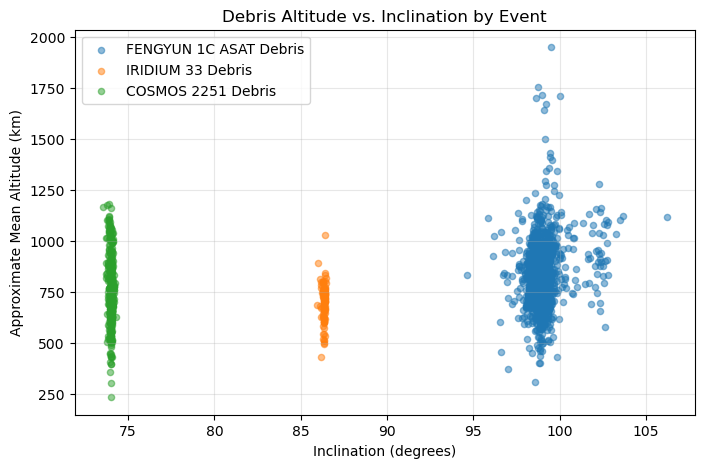

In [11]:
plt.figure(figsize=(8, 5))

for event_name in debris["debris_event"].unique():
    subset = debris[debris["debris_event"] == event_name]
    plt.scatter(
        subset["inclination_deg"],
        subset["altitude_km"],
        alpha=0.5,
        s=20,
        label=event_name
    )

plt.xlabel("Inclination (degrees)")
plt.ylabel("Approximate Mean Altitude (km)")
plt.title("Debris Altitude vs. Inclination by Event")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

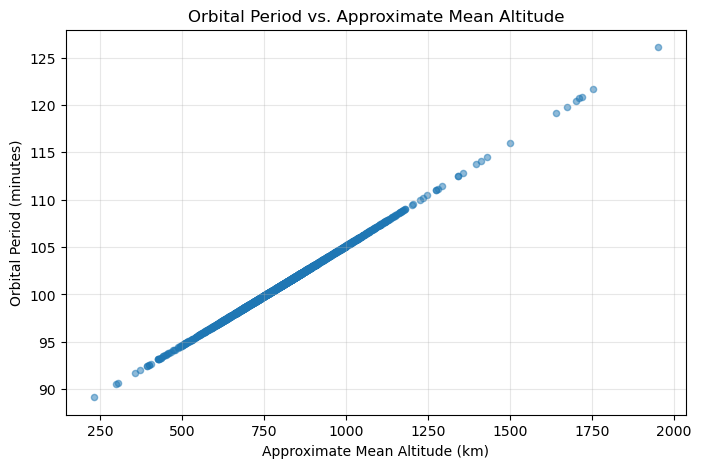

In [12]:
plt.figure(figsize=(8, 5))
plt.scatter(debris["altitude_km"], debris["period_min"], alpha=0.5, s=20)
plt.xlabel("Approximate Mean Altitude (km)")
plt.ylabel("Orbital Period (minutes)")
plt.title("Orbital Period vs. Approximate Mean Altitude")
plt.grid(alpha=0.3)
plt.show()

## 5. Compare the altitude distribution with a normal distribution

A density overlay and Q–Q plot are used as visual checks. These plots do not establish that the debris population is normally distributed.

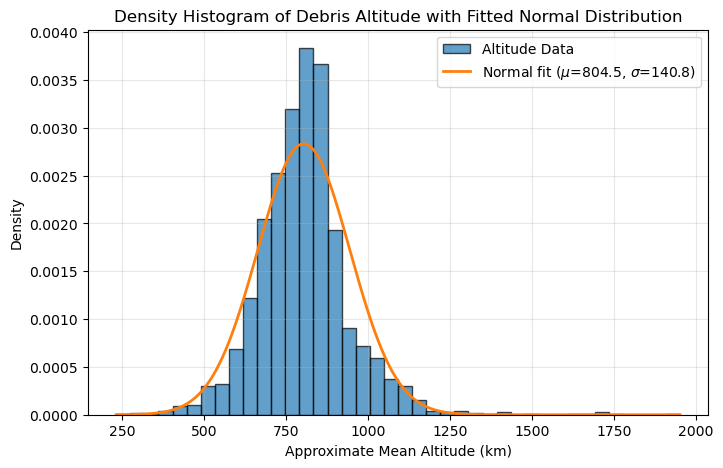

In [13]:
altitude = debris["altitude_km"]

mu_alt = altitude.mean()
sigma_alt = altitude.std()

x = np.linspace(altitude.min(), altitude.max(), 500)
normal_pdf = norm.pdf(x, mu_alt, sigma_alt)

plt.figure(figsize=(8, 5))
plt.hist(altitude, bins=40, density=True, edgecolor="black", alpha=0.7, label="Altitude Data")
plt.plot(x, normal_pdf, linewidth=2, label=f"Normal fit ($\\mu$={mu_alt:.1f}, $\\sigma$={sigma_alt:.1f})")
plt.xlabel("Approximate Mean Altitude (km)")
plt.ylabel("Density")
plt.title("Density Histogram of Debris Altitude with Fitted Normal Distribution")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

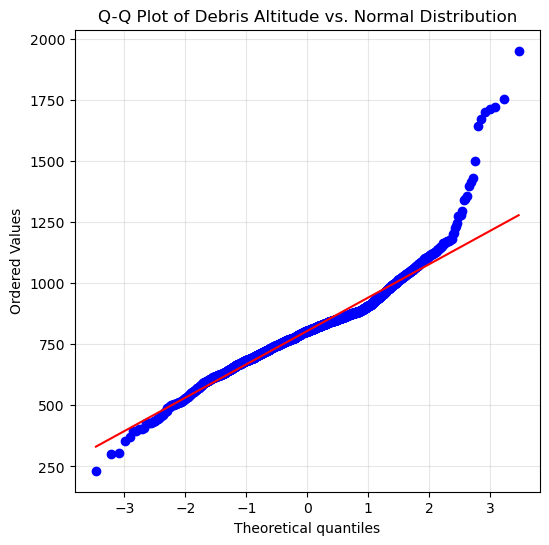

In [14]:
plt.figure(figsize=(6, 6))
probplot(altitude, dist="norm", plot=plt)
plt.title("Q-Q Plot of Debris Altitude vs. Normal Distribution")
plt.grid(alpha=0.3)
plt.show()

## 6. Bootstrap example

A small random sample is used to demonstrate how a bootstrap confidence interval for the mean can be constructed. This section is included as an uncertainty-analysis exercise rather than as a claim about the full physical population.

In [15]:
np.random.seed(93)

sample = altitude.sample(n=10, random_state=93)
bootstrap_means = []

for _ in range(5000):
    boot_sample = sample.sample(n=10, replace=True)
    bootstrap_means.append(boot_sample.mean())

bootstrap_means = np.array(bootstrap_means)

ci_lower = np.percentile(bootstrap_means, 2.5)
ci_upper = np.percentile(bootstrap_means, 97.5)

print("Sample values:")
print(sample.values)

print(f"Population mean altitude: {altitude.mean():.2f} km")
print(f"Sample mean altitude: {sample.mean():.2f} km")
print(f"95% bootstrap CI: ({ci_lower:.2f}, {ci_upper:.2f}) km")

Sample values:
[ 734.30977874 1087.76320017  871.42356281  830.6899736   704.46468651
  844.39094674  859.09915038  842.74411845  872.58224119  769.91888404]
Population mean altitude: 804.51 km
Sample mean altitude: 841.74 km
95% bootstrap CI: (786.47, 907.28) km


## 7. Simple linear regression

The first model asks whether inclination alone predicts approximate mean altitude.

In [17]:
X = debris[["inclination_deg"]]
y = debris["altitude_km"]

model = LinearRegression()
model.fit(X, y)

predicted_altitude = model.predict(X)
residuals = y - predicted_altitude

r_squared = r2_score(y, predicted_altitude)

print(f"Intercept: {model.intercept_:.3f} km")
print(f"Slope: {model.coef_[0]:.3f} km per degree")
print(f"R-squared: {r_squared:.4f}")

Intercept: 434.431 km
Slope: 3.985 km per degree
R-squared: 0.0866


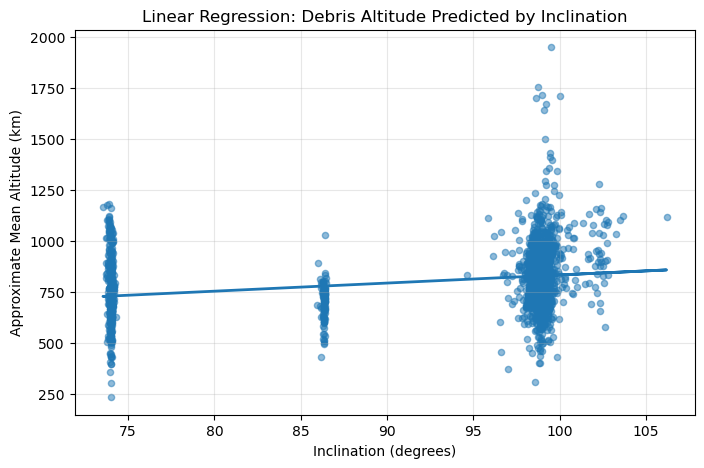

In [18]:
plt.figure(figsize=(8, 5))
plt.scatter(debris["inclination_deg"], debris["altitude_km"], alpha=0.5, s=20)
plt.plot(debris["inclination_deg"], predicted_altitude, linewidth=2)
plt.xlabel("Inclination (degrees)")
plt.ylabel("Approximate Mean Altitude (km)")
plt.title("Linear Regression: Debris Altitude Predicted by Inclination")
plt.grid(alpha=0.3)
plt.show()

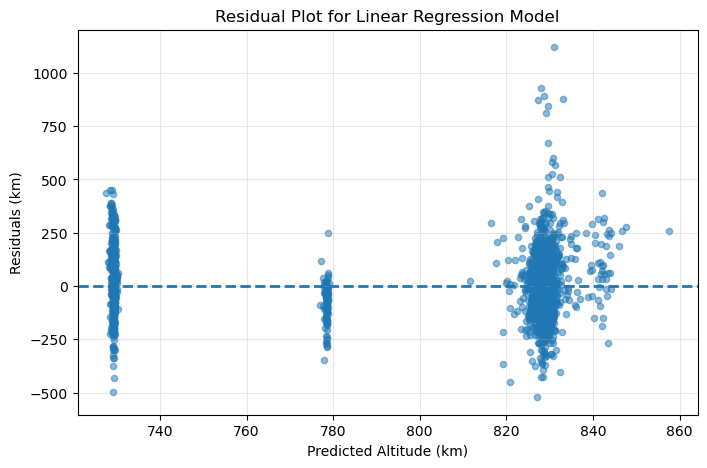

In [19]:
plt.figure(figsize=(8, 5))
plt.scatter(predicted_altitude, residuals, alpha=0.5, s=20)
plt.axhline(0, linestyle="--", linewidth=2)
plt.xlabel("Predicted Altitude (km)")
plt.ylabel("Residuals (km)")
plt.title("Residual Plot for Linear Regression Model")
plt.grid(alpha=0.3)
plt.show()

## 8. Add debris-event identity

Different debris events originate from different parent spacecraft and initial orbital conditions. Adding the event label tests whether event membership captures some structure not represented by inclination alone.

In [20]:
event_encoded = pd.get_dummies(debris["debris_event"], drop_first=True)

X_event = pd.concat([debris[["inclination_deg"]], event_encoded], axis=1)
y = debris["altitude_km"]

event_model = LinearRegression()
event_model.fit(X_event, y)

event_predictions = event_model.predict(X_event)
event_r_squared = r2_score(y, event_predictions)

print(f"Raw inclination-only model R-squared: {r_squared:.4f}")
print(f"Inclination + debris event model R-squared: {event_r_squared:.4f}")

Raw inclination-only model R-squared: 0.0866
Inclination + debris event model R-squared: 0.1138


Inclination alone may not explain debris altitude well because different debris events are generated from different parent spacecraft, collision geometries, breakup energies, and initial orbital regimes. Adding the debris event label tests whether population structure is better explained by event origin rather than by inclination alone.

## 9. Results and interpretation

For the cached notebook snapshot:

- **2,646** cataloged objects were included after cleaning.
- Mean approximate altitude: **804.5 km**.
- Median approximate altitude: **804.0 km**.
- Inclination–altitude correlation: **0.294**, a weak positive linear association.
- Inclination-only linear model: **R² = 0.0866**.
- Inclination + debris-event model: **R² = 0.1138**.

The main result is not that inclination determines debris altitude. In this dataset, inclination alone explains only a small fraction of altitude variation. Event identity adds some explanatory power, suggesting that the current orbital population retains structure associated with different debris-producing events.

## Limitations

1. **Current surviving catalog only.** Atmospheric drag, perturbations, reentry, and catalog maintenance have altered the populations since the original breakup events.
2. **Approximate altitude proxy.** `altitude_km` is derived from semi-major axis and does not represent instantaneous altitude, perigee, or apogee.
3. **Exploratory, not causal.** Correlation and regression describe associations; they do not identify breakup physics or causal mechanisms.
4. **Current GP data change with time.** Re-running the notebook later may produce different object counts and summary statistics.
5. **No orbit propagation.** This notebook does not model future decay, conjunction risk, or long-term debris evolution.

## Takeaway

This project demonstrates a reproducible workflow for public space-domain data:

**catalog ingestion → cleaning → orbital-variable derivation → visualization → uncertainty analysis → simple modeling → interpretation of limitations**